In [11]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import numpy as np
from calibration import lifetime_to_temperature_201112, pict_calibration
from scipy.optimize import curve_fit
import seaborn as sns
from PIL import Image
import scipy as sp
import cv2
from matplotlib.backends.backend_pdf import PdfPages

In [12]:
#PATHの読み込み
intensity_path = []
lifetime_path = []
files = glob.glob('./150mW_1sec_50rep_cell05/150mW_1sec_50rep_2_150mW_1sec_50rep_64_2_?/')
files.sort()
for file in files:
    path = glob.glob(file + '/*ch00.tif')
    path.sort()
    intensity_path += path
    path = glob.glob(file + '/*ch01.tif')
    path.sort()    
    lifetime_path += path

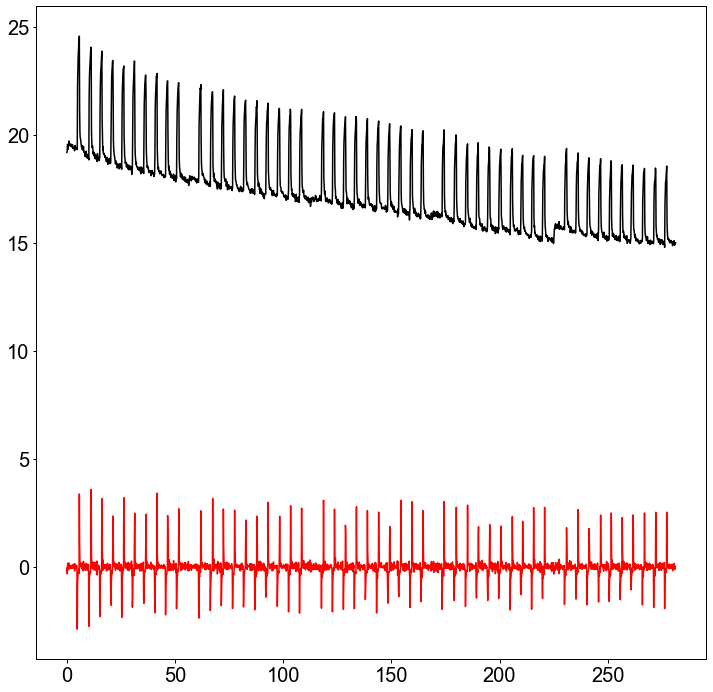

In [13]:
#IRレーザーがoffになるタイミングを探す
int_mean = []

for files in intensity_path:


    #加熱中心の強度変化
    int_image = np.array(Image.open(files))
    mean = np.mean(int_image)
    int_mean.append(mean)

diff = np.array(int_mean)[:-1] - np.array(int_mean)[1:]

#体裁調整
fig = plt.figure(figsize = (12, 12))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams["font.size"] = 20

off_index = pd.DataFrame(diff)
off_index = np.ravel(off_index[off_index[0] > 1].index)

time_diff = [i*0.137 for i in range(len(diff))]
time_int = [i*0.137 for i in range(len(int_mean))]
plt.plot(time_diff, diff, color = 'red')
plt.plot(time_int, int_mean, color = 'black')


off_index_corrected = []
for index in off_index:
    max_index = pd.DataFrame(diff)[index - 5: index + 5][0].idxmax()
    off_index_corrected.append(max_index)
off_index_corrected = pd.DataFrame(off_index_corrected).drop_duplicates()

#pdfのセーブ
pp = PdfPages('./map_trace_int.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(diff).to_csv('diff.csv')
pd.DataFrame(int_mean).to_csv('int_mean.csv')